In [1]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential
from keras.layers import Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
x_data = np.array( [[0,0],[0,1],[1,0],[1,1]] )
y_data = np.array( [[0],[1],[1],[0]])

In [3]:
x = tf.constant( x_data, tf.float32)
y = tf.constant( y_data, tf.float32)

In [4]:
initX = tf.initializers.GlorotUniform()
w1 = tf.Variable( initX(shape=[2,100]))
b1 = tf.Variable( initX(shape=[100]) ) 
w2 = tf.Variable( initX(shape=[100,1]))
b2 = tf.Variable( initX(shape=[1]) ) 

# w1 = tf.Variable( initX(shape=[2,2]))
# b1 = tf.Variable( initX(shape=[2]) ) 
# w2 = tf.Variable( initX(shape=[2,1]))
# b2 = tf.Variable( initX(shape=[1]) ) 

In [5]:
lr = 0.01
optimizer = tf.keras.optimizers.Adam( learning_rate=lr)
for i in range(500):
    with tf.GradientTape() as tape:
        z1 = tf.matmul(x,w1) + b1
        hx1 = tf.nn.sigmoid( z1 )
        z = tf.matmul(hx1,w2) +b2
        # hx = tf.nn.sigmoid(z)
        cost_i = tf.nn.sigmoid_cross_entropy_with_logits(labels=y, logits=z)
        cost = tf.reduce_mean( cost_i)
    
    gradients = tape.gradient( cost, [w1,w2,b1,b2] )
    optimizer.apply_gradients(  zip( gradients,[w1,w2,b1,b2] )  )
    print( 'cost', cost.numpy())
print('최종w1', w1.numpy() )
print('최종w2', w2.numpy() )
print('최종b1', b1.numpy() )
print('최종b2', b2.numpy() )

cost 0.7004577
cost 0.73024344
cost 0.7000378
cost 0.70716506
cost 0.7163576
cost 0.7085935
cost 0.6987263
cost 0.6977054
cost 0.70311004
cost 0.70547646
cost 0.70193034
cost 0.69692147
cost 0.6952795
cost 0.69740987
cost 0.6996531
cost 0.6990613
cost 0.69635665
cost 0.69427776
cost 0.6944541
cost 0.6959382
cost 0.69659925
cost 0.6956049
cost 0.6940387
cost 0.6934136
cost 0.6940249
cost 0.6948131
cost 0.69472563
cost 0.69386554
cost 0.6931768
cost 0.69327635
cost 0.69381785
cost 0.6940245
cost 0.69364136
cost 0.693141
cost 0.69306207
cost 0.69337344
cost 0.69359505
cost 0.693438
cost 0.69312
cost 0.6930214
cost 0.69319636
cost 0.6933554
cost 0.69327843
cost 0.6930796
cost 0.6930095
cost 0.6931145
cost 0.6932081
cost 0.69315016
cost 0.69302255
cost 0.69298583
cost 0.693053
cost 0.69309556
cost 0.6930398
cost 0.69295853
cost 0.69294775
cost 0.6929896
cost 0.69299585
cost 0.6929435
cost 0.6928966
cost 0.6929008
cost 0.69292057
cost 0.6929042
cost 0.6928614
cost 0.6928393
cost 0.6928464
co

In [6]:
print('최종w1', w1.numpy() )
print('최종w2', w2.numpy() )
print('최종b1', b1.numpy() )
print('최종b2', b2.numpy() )

최종w1 [[ 0.6243179  -1.402893   -0.944142    2.4483538  -3.7241533  -0.49177715
   1.4768727  -0.41895685  0.34346753  1.244694   -0.33789033  1.3480171
  -0.04757947  1.1469052   1.5920678  -0.5133789  -1.1968781  -3.856531
  -1.2638274  -1.2925811   1.0586693  -0.5255981  -3.7864795  -4.202485
   0.90381366 -0.42741555 -0.46151704 -0.52667886 -0.57538354 -0.65813076
  -0.38647223 -0.4052523  -1.9209708  -0.27957892  2.6246164  -3.819918
   0.42848176  0.60515654 -0.6100849  -2.6023283   3.9544413  -0.2917861
   0.28727433 -0.44769067  0.7549986   0.7999964  -0.47403806 -0.36062944
  -0.4404013  -0.4350195  -0.4590746   0.26570192 -3.7470257   0.81782705
   0.85402364 -0.5965935   0.5859638  -0.6210168   0.92245495 -0.7768968
  -0.8959424  -3.6993845  -0.3329802   1.8926063   3.7966      0.42454106
  -0.17234926  0.89777213  0.6057017   2.4970548  -0.47979698 -0.2939225
   0.9530674   4.3650904  -0.3665163   1.5828696  -0.4383807   0.49304613
  -2.6296678   0.62577534 -0.5411818   3.60

In [7]:
def hxfn(xd):
    xd = tf.constant( xd, tf.float32)
    z1 = tf.matmul(xd,w1) + b1
    hx1 = tf.sigmoid( z1 )
    z = tf.matmul( hx1, w2) + b2
    hx = tf.sigmoid(z)
    return (hx.numpy() > 0.5) +0

In [8]:
hxfn( x ) #4x2 2x100 = 4x100 100x1 = 4x1
#4x2 2x2  4x2 2x1 = 4x1

array([[0],
       [1],
       [1],
       [0]])

과제
---------
sklearn 의 breast_cancer 데이터셋

1. train, test 나누기
2. 정규화
3. 케라스 학습
4. train, test 각각 confusion matrix(heat map 포함), f1, acc
5. 1번째행 예측값

In [32]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sb

matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False


In [47]:
bc = load_breast_cancer( as_frame=True)
df=bc['frame']
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [48]:
x_train,x_test,y_train,y_test=train_test_split(
    df.iloc[:,:-1],
    df.iloc[:,-1],
    test_size=0.2,
    stratify=df.iloc[:,-1],
    random_state=42
)

In [49]:
st=StandardScaler()
x_train=st.fit_transform(x_train)
x_test=st.fit_transform(x_test)
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

In [51]:
dense=Dense(units=1,input_dim=30, activation='sigmoid')
model = Sequential([dense])
model.compile( loss='binary_crossentropy', optimizer=Adam(0.001) , metrics=['acc'])
h = model.fit( x_train, y_train, epochs=500)

Epoch 1/500


c:\Users\Dell5371\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.8813 - loss: 0.3323  
Epoch 2/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9011 - loss: 0.3046 
Epoch 3/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9121 - loss: 0.2817 
Epoch 4/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9209 - loss: 0.2626 
Epoch 5/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9319 - loss: 0.2464 
Epoch 6/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9363 - loss: 0.2327 
Epoch 7/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9407 - loss: 0.2208 
Epoch 8/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9495 - loss: 0.2106 
Epoch 9/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9516 - loss: 0.2012 
Epoch 10/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9538 - loss: 0.1925 
Epoch 11/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9538 - loss: 0.1851 
Epoch 12/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9538 - loss: 0.1783 
Epoch 13/500
15/15 ━━━━━━━━━━━━━━━━━

In [53]:
train_pred=(model.predict(x_train)>0.5).astype(int)
test_pred=(model.predict(x_test)>0.5).astype(int)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


train f1 : 0.9882186006286866
test f1 : 0.9811507936507937
train 정확도 : 0.989010989010989
test 정확도 : 0.9824561403508771


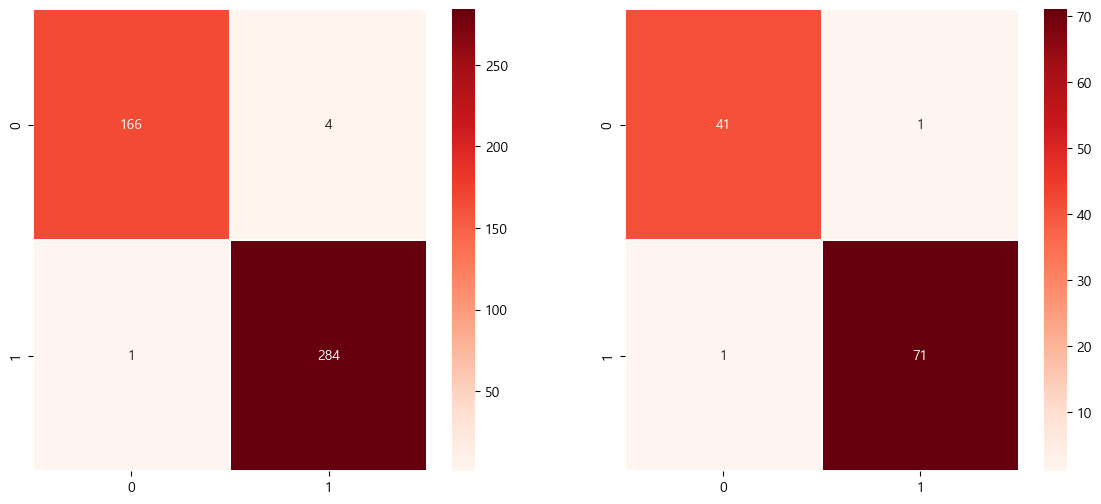

In [64]:
plt.figure(figsize=(14, 6))
c=confusion_matrix(y_train, train_pred)
plt.subplot(1,2,1)
sb.heatmap( c, 
           annot=True, 
           fmt='d',
           linewidths=0.2, 
           cmap='Reds',
           )


c=confusion_matrix(y_test, test_pred)
plt.subplot(1,2,2)
sb.heatmap( c, 
           annot=True, 
           fmt='d',
           linewidths=0.2, 
           cmap='Reds',
           )

print("train f1 :", f1_score(y_train, train_pred, average="macro"))
print("test f1 :", f1_score(y_test, test_pred, average="macro"))
print("train 정확도 :", accuracy_score(y_train, train_pred))
print("test 정확도 :", accuracy_score(y_test, test_pred))

In [62]:
(model.predict(df.iloc[1:2, :-1]) > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[0]])